In [ ]:
import tensorflow as tr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
(x_train,y_train),(x_test,y_test)=tr.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9825s 58us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
print(y_train[:10])

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


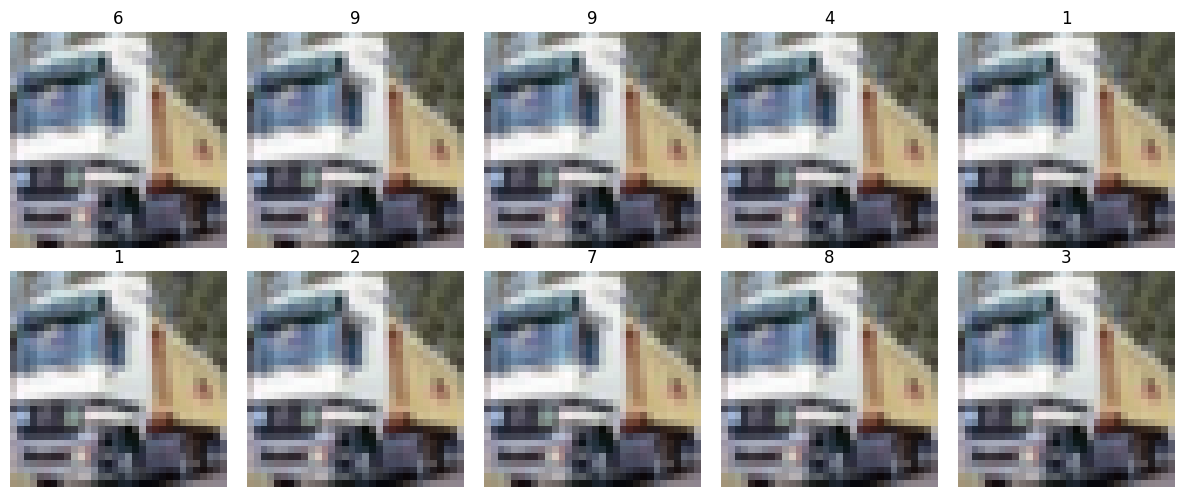

In [ ]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[1])
    plt.title(y_train[i][0])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

In [ ]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [ ]:
x_train=x_train/255.0
x_test = x_test/255.0

print('Minimum: ',x_train.min())
print('Maximum: ',x_train.max())

Minimum:  0.0
Maximum:  1.0


In [ ]:
model=tr.keras.Sequential([
    tr.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tr.keras.layers.MaxPooling2D((2,2)),
    tr.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tr.keras.layers.MaxPooling2D((2,2)),
    tr.keras.layers.Flatten(),
    tr.keras.layers.Dense(64,activation='relu'),
    tr.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=6,batch_size=20,validation_split=0.2)

Epoch 1/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - accuracy: 0.4813 - loss: 1.4535 - val_accuracy: 0.5686 - val_loss: 1.2322
Epoch 2/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 55s 27ms/step - accuracy: 0.6140 - loss: 1.0968 - val_accuracy: 0.6263 - val_loss: 1.0743
Epoch 3/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.6633 - loss: 0.9691 - val_accuracy: 0.6508 - val_loss: 0.9973
Epoch 4/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - accuracy: 0.6936 - loss: 0.8761 - val_accuracy: 0.6639 - val_loss: 0.9803
Epoch 5/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.7213 - loss: 0.8018 - val_accuracy: 0.6726 - val_loss: 0.9504
Epoch 6/6
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - accuracy: 0.7427 - loss: 0.7344 - val_accuracy: 0.6767 - val_loss: 0.9695


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


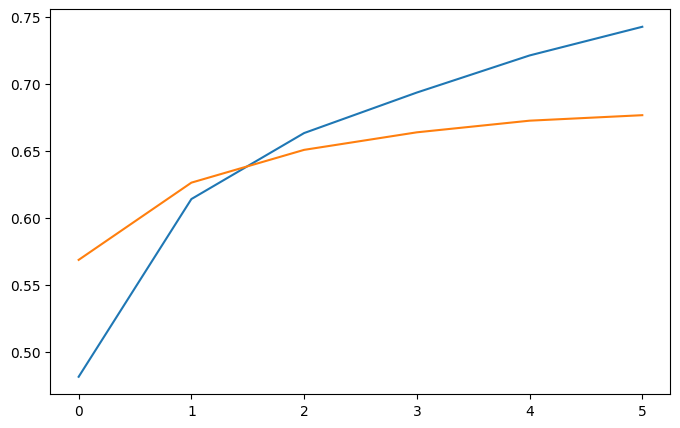

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.show()

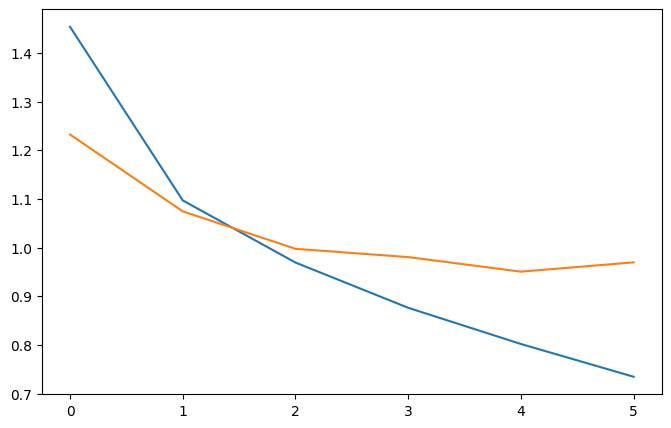

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.show()

In [ ]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [ ]:
predicted_label=np.argmax(predictions[0])
print('Predicted digit: ',predicted_label)
print('Actual digit: ',y_test[0])

Predicted digit:  3
Actual digit:  [3]


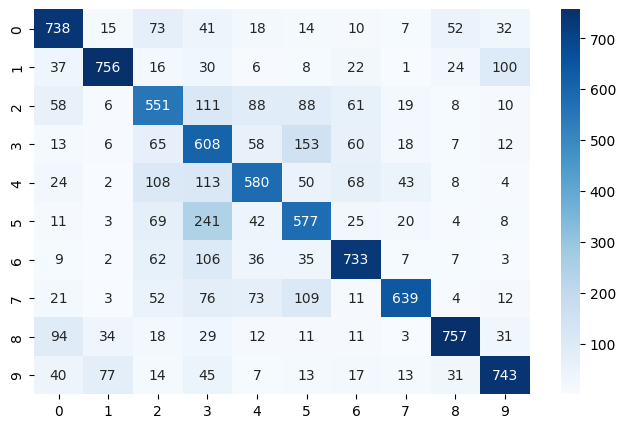

In [ ]:
y_pred=np.argmax(predictions,axis=1)
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,5))
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d')
plt.show()

In [ ]:
cr=classification_report(y_test,y_pred)
print('Classification Report:\n ',cr)

Classification Report:
                precision    recall  f1-score   support

           0       0.71      0.74      0.72      1000
           1       0.84      0.76      0.79      1000
           2       0.54      0.55      0.54      1000
           3       0.43      0.61      0.51      1000
           4       0.63      0.58      0.60      1000
           5       0.55      0.58      0.56      1000
           6       0.72      0.73      0.73      1000
           7       0.83      0.64      0.72      1000
           8       0.84      0.76      0.80      1000
           9       0.78      0.74      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.69      0.67      0.67     10000
weighted avg       0.69      0.67      0.67     10000

